# PubMedQA Classification with Advanced QLoRA (Qwen 2.5 7B SOTA)

This notebook fine-tunes a larger instruct model for PubMedQA 3-way classification (`yes`/`no`/`maybe`) using advanced QLoRA and metric-oriented evaluation.

## Advanced Improvements

- Uses `Qwen2.5-14B-Instruct` in 4-bit (with easy fallback to 7B if needed)
- Uses context compression to keep the most question-relevant evidence
- Uses class balancing plus dual-format supervision (reasoning+decision and decision-only)
- Uses larger LoRA capacity (`r=64`, `alpha=128`)
- Uses early stopping + best checkpoint by validation loss
- Uses score-based candidate classification (log-likelihood over `yes/no/maybe`) for stronger and more stable metrics
- Includes full EDA on data and post-training errors

## 1. Install Required Dependencies

In [1]:
# Kaggle-friendly dependencies
!pip install -q transformers>=4.44.0
!pip install -q datasets>=2.20.0
!pip install -q accelerate>=0.33.0
!pip install -q peft>=0.12.0
!pip install -q bitsandbytes>=0.43.1
!pip install -q trl>=0.10.1
!pip install -q scikit-learn matplotlib seaborn rouge-score sentencepiece protobuf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 2. Import Libraries and Setup

In [2]:
import os
import gc
import re
import random
import warnings
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch: 2.10.0+cu128
CUDA available: True | GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 3. Configuration (OPTIMIZED)

In [3]:
# Model and run configuration (advanced)
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
NEW_MODEL_NAME = "Qwen2.5-7B-PubMedQA-SOTA"

# Training hyperparameters (optimized for 2x T4)
EPOCHS = 3
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 1.2e-4
MAX_SEQ_LENGTH = 1024
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01

# LoRA capacity (higher than baseline)
LORA_R = 64
LORA_ALPHA = 128
LORA_DROPOUT = 0.05

# Generation and evaluation
MAX_NEW_TOKENS = 32
EVAL_MAX_SAMPLES = None  # None = full validation set

LABEL_NAMES = ["yes", "no", "maybe"]
LABEL_SET = set(LABEL_NAMES)

OUTPUT_DIR = "./results_qwen_pubmed_advanced"
CHECKPOINT_DIR = "./checkpoints_qwen_pubmed_advanced"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print({
    "model": MODEL_NAME,
    "fallback": FALLBACK_MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "grad_accum": GRADIENT_ACCUMULATION_STEPS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
})

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'fallback': 'Qwen/Qwen2.5-7B-Instruct', 'epochs': 3, 'batch_size': 1, 'grad_accum': 16, 'max_seq_length': 1024, 'lora_r': 64, 'lora_alpha': 128, 'lora_dropout': 0.05}


## 4. Load Data and Basic Data EDA

In [4]:
# Load PubMedQA labeled subset
url = "https://raw.githubusercontent.com/pubmedqa/pubmedqa/master/data/ori_pqal.json"
response = requests.get(url, timeout=60)
response.raise_for_status()
data_dict = response.json()

df = pd.DataFrame.from_dict(data_dict, orient="index").reset_index().rename(columns={"index": "pubmed_id"})
df = df.dropna(subset=["QUESTION", "CONTEXTS", "final_decision"]).copy()
df = df[df["final_decision"].isin(LABEL_NAMES)].reset_index(drop=True)

print(f"Loaded {len(df)} rows")
print("Columns:", df.columns.tolist())

Loaded 1000 rows
Columns: ['pubmed_id', 'QUESTION', 'CONTEXTS', 'LABELS', 'MESHES', 'YEAR', 'reasoning_required_pred', 'reasoning_free_pred', 'final_decision', 'LONG_ANSWER']


Class distribution: {'yes': 552, 'no': 338, 'maybe': 110}
Average lengths:
q_len       12.91
ctx_len    200.21
ans_len     39.66
dtype: float64


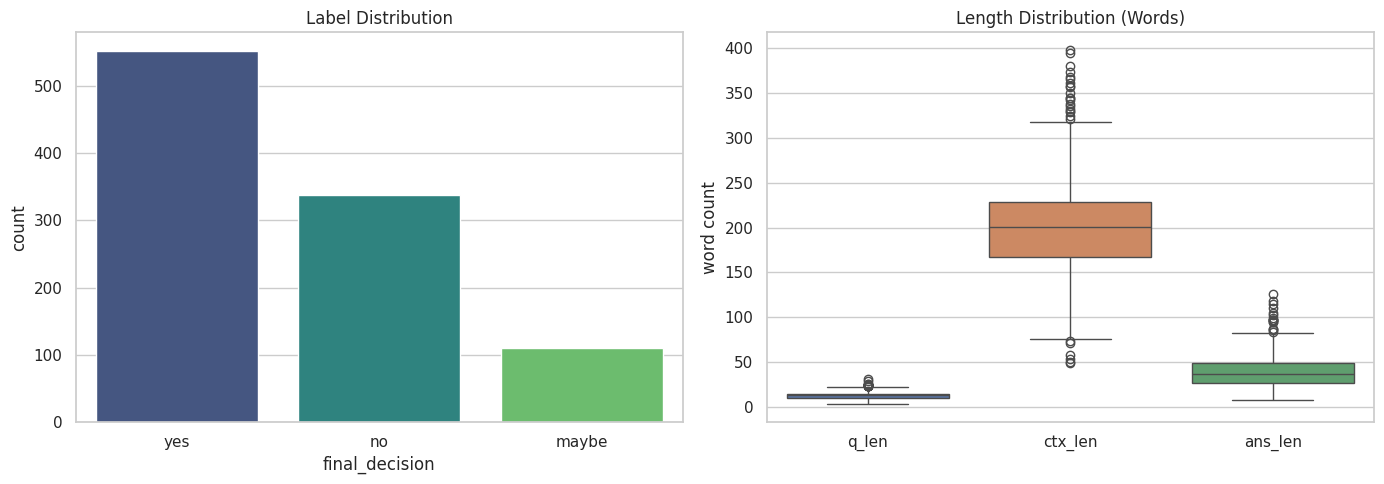

In [5]:
# Basic EDA: class distribution and text-length profile
df["q_len"] = df["QUESTION"].astype(str).apply(lambda x: len(x.split()))
df["ctx_len"] = df["CONTEXTS"].apply(lambda x: len(" ".join(x).split()) if isinstance(x, list) else len(str(x).split()))
df["ans_len"] = df["LONG_ANSWER"].astype(str).apply(lambda x: len(x.split()))

print("Class distribution:", df["final_decision"].value_counts().to_dict())
print("Average lengths:")
print(df[["q_len", "ctx_len", "ans_len"]].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="final_decision", order=LABEL_NAMES, ax=axes[0], hue="final_decision", palette="viridis", legend=False)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("final_decision")
axes[0].set_ylabel("count")

sns.boxplot(data=df[["q_len", "ctx_len", "ans_len"]], ax=axes[1])
axes[1].set_title("Length Distribution (Words)")
axes[1].set_ylabel("word count")

plt.tight_layout()
plt.show()

## 5. Prompt Formatting and Balanced Split

In [6]:
def tokenize_simple(text):
    text = re.sub(r"[^a-z0-9\s]", " ", str(text).lower())
    return [t for t in text.split() if len(t) > 2]

def compress_context(contexts, question, max_words=520, top_k=6):
    """Select most question-relevant context chunks by token overlap."""
    if isinstance(contexts, list):
        chunks = [str(c) for c in contexts if str(c).strip()]
    else:
        chunks = [str(contexts)]

    q_tokens = set(tokenize_simple(question))
    scored = []
    for chunk in chunks:
        c_tokens = set(tokenize_simple(chunk))
        overlap = len(q_tokens.intersection(c_tokens))
        scored.append((overlap, chunk))

    scored.sort(key=lambda x: x[0], reverse=True)
    selected = [x[1] for x in scored[:top_k]] if len(scored) > top_k else [x[1] for x in scored]
    merged = " ".join(selected)
    return " ".join(merged.split()[:max_words])

def format_train_prompt_reasoning(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    long_answer = str(row.get("LONG_ANSWER", "")).strip()
    decision = str(row["final_decision"]).strip().lower()

    if not long_answer:
        long_answer = "Evidence supports the final decision based on the provided biomedical context."

    return f"""### System:
You are a biomedical QA assistant. Read the context and answer the question.
Return concise reasoning then a final decision from this set: yes, no, maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Reasoning: {long_answer}
Final Decision: {decision}""".strip()

def format_train_prompt_decision_only(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    decision = str(row["final_decision"]).strip().lower()

    return f"""### System:
You are a biomedical QA assistant. Output only one label.
Valid labels: yes, no, maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Final Decision: {decision}""".strip()

def format_inference_prompt(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    return f"""### System:
You are a biomedical QA assistant.
Return exactly one line in this format: Final Decision: yes|no|maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Final Decision:""".strip()

In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df["final_decision"],
)

print("Original train distribution:", train_df["final_decision"].value_counts().to_dict())
print("Validation distribution:", val_df["final_decision"].value_counts().to_dict())

def oversample_train(input_df, label_col="final_decision", seed=42):
    counts = input_df[label_col].value_counts()
    target = counts.max()
    chunks = []
    for label in LABEL_NAMES:
        part = input_df[input_df[label_col] == label]
        sampled = part.sample(target, replace=True, random_state=seed)
        chunks.append(sampled)
    out = pd.concat(chunks).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_df_balanced = oversample_train(train_df, seed=SEED)
print("Balanced train distribution:", train_df_balanced["final_decision"].value_counts().to_dict())

# Dual-format supervision for better metric alignment
train_reasoning = train_df_balanced.copy()
train_reasoning["text"] = train_reasoning.apply(format_train_prompt_reasoning, axis=1)

train_decision = train_df_balanced.copy()
train_decision["text"] = train_decision.apply(format_train_prompt_decision_only, axis=1)

train_mixed = pd.concat([train_reasoning, train_decision], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df = val_df.copy()
val_df["text"] = val_df.apply(format_train_prompt_reasoning, axis=1)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_mixed[["text"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_df[["text"]], preserve_index=False),
})

print(f"Train size (balanced + dual format): {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")

Original train distribution: {'yes': 497, 'no': 304, 'maybe': 99}
Validation distribution: {'yes': 55, 'no': 34, 'maybe': 11}
Balanced train distribution: {'no': 497, 'yes': 497, 'maybe': 497}
Train size (balanced + dual format): 2982
Validation size: 100


## 6. QLoRA Setup (4-bit) and Model Loading

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("4-bit quantization config initialized")

4-bit quantization config initialized


In [9]:
# Load tokenizer and determine active model name (with fallback)
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    active_model_name = MODEL_NAME
except Exception as exc:
    print(f"Primary tokenizer load failed: {exc}")
    tokenizer = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME, trust_remote_code=True)
    active_model_name = FALLBACK_MODEL_NAME

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokenizer ready: {active_model_name}")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer ready: Qwen/Qwen2.5-7B-Instruct


In [10]:
# Load model aligned with tokenizer-selected active_model_name
try:
    model = AutoModelForCausalLM.from_pretrained(
        active_model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        use_cache=False,
        torch_dtype=torch.float16,
    )
except Exception as exc:
    if active_model_name != FALLBACK_MODEL_NAME:
        print(f"Primary model failed to load: {exc}")
        print(f"Falling back to: {FALLBACK_MODEL_NAME}")
        active_model_name = FALLBACK_MODEL_NAME
        model = AutoModelForCausalLM.from_pretrained(
            active_model_name,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            use_cache=False,
            torch_dtype=torch.float16,
        )
    else:
        raise

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

print(f"Base model loaded and prepared for k-bit training: {active_model_name}")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Base model loaded and prepared for k-bit training: Qwen/Qwen2.5-7B-Instruct


## 7. LoRA Adapters

In [11]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 161,480,704 || all params: 7,777,097,216 || trainable%: 2.0764


## 8. Training Arguments (Validation-Aware)

In [12]:
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    dataloader_pin_memory=False,
    seed=SEED,
)

# SFT-specific settings
training_args.max_seq_length = MAX_SEQ_LENGTH
training_args.dataset_text_field = "text"
training_args.packing = False

print("Training args configured")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args configured


## 9. Evaluation Helpers (Strict Decision Extraction)

In [13]:
decision_pattern = re.compile(r"final\s*decision\s*:\s*(yes|no|maybe)", re.IGNORECASE)

def extract_decision(text):
    match = decision_pattern.search(str(text))
    if match:
        return match.group(1).lower()
    return "unknown"

@torch.no_grad()
def candidate_logprob(model, tokenizer, prompt, candidate):
    """Compute normalized conditional log-probability for candidate label."""
    full_text = prompt + " " + candidate
    enc_full = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
    enc_prompt = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)

    input_ids = enc_full["input_ids"]
    attention_mask = enc_full["attention_mask"]
    prompt_len = enc_prompt["input_ids"].shape[1]

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits[:, :-1, :]
    labels = input_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(dim=-1, index=labels.unsqueeze(-1)).squeeze(-1)

    start = max(prompt_len - 1, 0)
    cand_token_log_probs = token_log_probs[:, start:]
    if cand_token_log_probs.numel() == 0:
        return -1e9

    return cand_token_log_probs.mean().item()

@torch.no_grad()
def predict_validation(model, tokenizer, frame, max_samples=None):
    model.eval()
    preds, trues = [], []

    n = len(frame) if max_samples is None else min(len(frame), max_samples)
    candidates = ["yes", "no", "maybe"]

    for idx in range(n):
        row = frame.iloc[idx]
        base_prompt = format_inference_prompt(row)

        scores = {cand: candidate_logprob(model, tokenizer, base_prompt, cand) for cand in candidates}
        pred = max(scores, key=scores.get)
        true_label = str(row["final_decision"]).lower()

        preds.append(pred if pred in LABEL_SET else "unknown")
        trues.append(true_label)

        if idx % 25 == 0:
            torch.cuda.empty_cache()

    return preds, trues

## 10. Initialize Trainer and Train

In [14]:
gc.collect()
torch.cuda.empty_cache()

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer initialized")

Adding EOS to train dataset:   0%|          | 0/2982 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2982 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Trainer initialized


In [15]:
# QLoRA stability step: keep trainable adapter params in fp32
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

gc.collect()
torch.cuda.empty_cache()

print(f"Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
train_result = trainer.train()
print(f"Training completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training started: 2026-06-16 21:38:28


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,0.548200,1.690012,1.317908,0.614085,1191359.000000
2,0.151428,2.064557,0.995512,0.597118,2382718.000000
3,0.055010,2.227026,0.918352,0.589814,3574077.000000


Training completed: 2026-06-17 02:48:15


In [16]:
print(f"Global steps: {train_result.global_step}")
print(f"Train loss: {train_result.training_loss:.4f}")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

Global steps: 561
Train loss: 0.4705
Best checkpoint: ./results_qwen_pubmed_advanced/checkpoint-187


## 11. Validation Metrics and Inference-Based Evaluation

In [17]:
# Loss-based eval from trainer
eval_results = trainer.evaluate()
print("Trainer eval:")
for k, v in eval_results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

Trainer eval:
eval_loss: 1.6900
eval_runtime: 73.7815
eval_samples_per_second: 1.3550
eval_steps_per_second: 1.3550
eval_entropy: 1.3179
eval_mean_token_accuracy: 0.6141
eval_num_tokens: 3574077.0000
epoch: 3.0000


## 12. Deterministic Classification Evaluation (Accuracy/F1)

In [18]:
all_predictions, all_true_labels = predict_validation(
    trainer.model,
    tokenizer,
    val_df.reset_index(drop=True),
    max_samples=EVAL_MAX_SAMPLES,
 )

valid_pairs = [
    (p, t) for p, t in zip(all_predictions, all_true_labels)
    if p in LABEL_SET and t in LABEL_SET
]

if len(valid_pairs) == 0:
    raise RuntimeError("No valid predictions extracted. Check prompt/output format.")

predictions, true_labels = zip(*valid_pairs)
predictions, true_labels = list(predictions), list(true_labels)

print(f"Total samples evaluated: {len(all_true_labels)}")
print(f"Valid extracted predictions: {len(predictions)}")
print(f"Unknown/invalid predictions: {len(all_true_labels) - len(predictions)}")

Total samples evaluated: 100
Valid extracted predictions: 100
Unknown/invalid predictions: 0


In [19]:
final_accuracy = accuracy_score(true_labels, predictions)
final_f1_macro = f1_score(true_labels, predictions, average="macro", labels=LABEL_NAMES, zero_division=0)
final_f1_weighted = f1_score(true_labels, predictions, average="weighted", labels=LABEL_NAMES, zero_division=0)

print("Final decision metrics")
print("=" * 50)
print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"F1 Macro: {final_f1_macro:.4f}")
print(f"F1 Weighted: {final_f1_weighted:.4f}")
print("=" * 50)

print("\nClassification report:")
print(classification_report(true_labels, predictions, labels=LABEL_NAMES, zero_division=0))

Final decision metrics
Accuracy: 0.7900 (79.00%)
F1 Macro: 0.5720
F1 Weighted: 0.7597

Classification report:
              precision    recall  f1-score   support

         yes       0.82      0.85      0.84        55
          no       0.82      0.94      0.88        34
       maybe       0.00      0.00      0.00        11

    accuracy                           0.79       100
   macro avg       0.55      0.60      0.57       100
weighted avg       0.73      0.79      0.76       100



## 13. Results EDA: Confusion Matrix, Error Profile, Training Curves

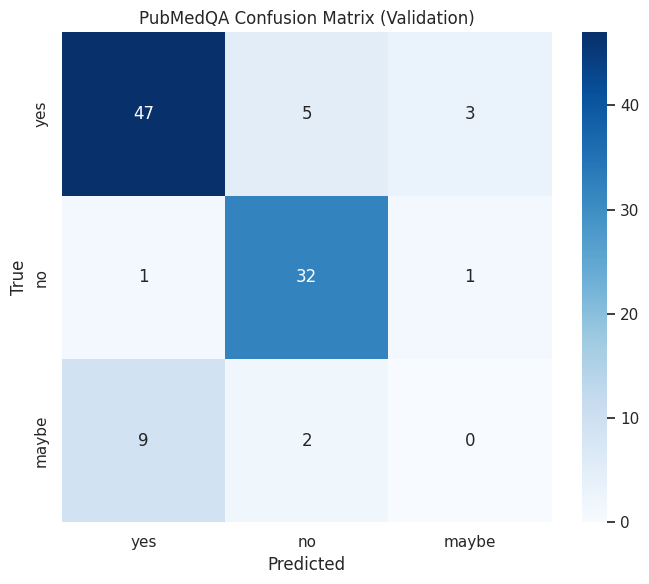

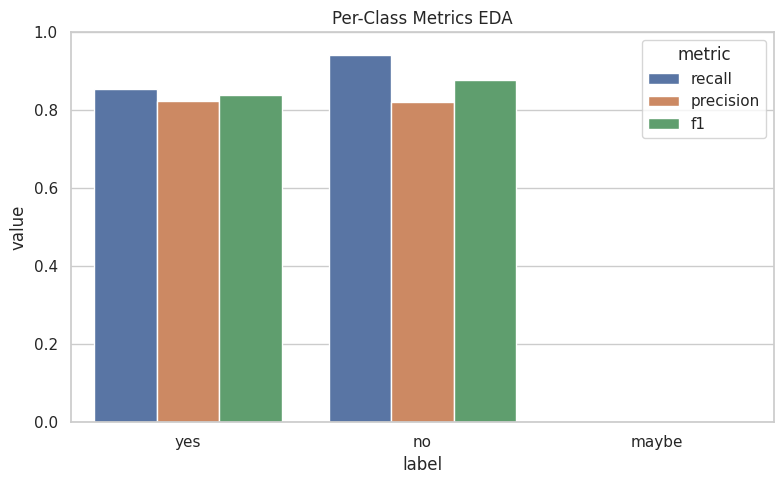

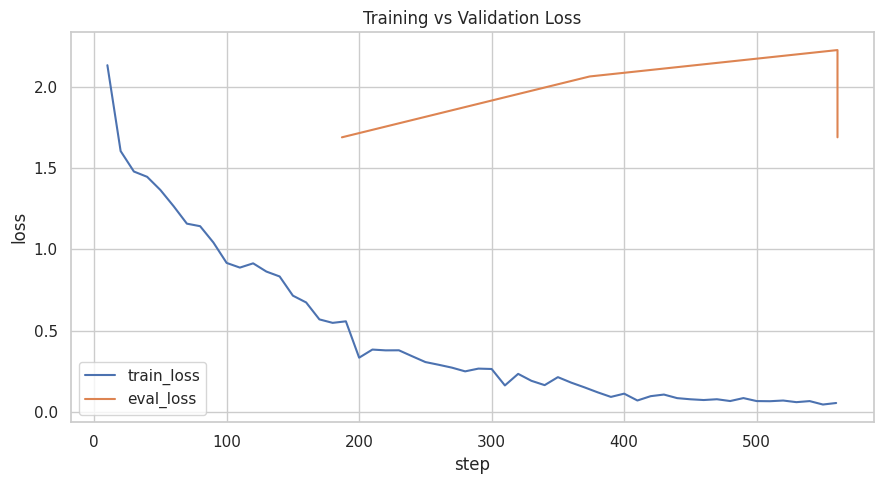

Saved prediction analysis to ./results_qwen_pubmed_advanced/validation_predictions.csv


In [20]:
# 1) Confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=LABEL_NAMES)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
 )
plt.title("PubMedQA Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# 2) Per-class metrics EDA
class_report = classification_report(
    true_labels,
    predictions,
    labels=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
 )
recall_frame = pd.DataFrame({
    "label": LABEL_NAMES,
    "recall": [class_report[label]["recall"] for label in LABEL_NAMES],
    "precision": [class_report[label]["precision"] for label in LABEL_NAMES],
    "f1": [class_report[label]["f1-score"] for label in LABEL_NAMES],
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=recall_frame.melt(id_vars="label", var_name="metric", value_name="value"),
    x="label",
    y="value",
    hue="metric",
)
plt.ylim(0, 1)
plt.title("Per-Class Metrics EDA")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_class_metrics.png", dpi=150)
plt.show()

# 3) Training dynamics EDA from trainer log history
log_df = pd.DataFrame(trainer.state.log_history)
train_log = log_df.dropna(subset=["loss", "step"])[["step", "loss"]].copy()
eval_log = log_df.dropna(subset=["eval_loss", "step"])[["step", "eval_loss"]].copy()

if len(train_log) > 0 or len(eval_log) > 0:
    plt.figure(figsize=(9, 5))
    if len(train_log) > 0:
        plt.plot(train_log["step"], train_log["loss"], label="train_loss")
    if len(eval_log) > 0:
        plt.plot(eval_log["step"], eval_log["eval_loss"], label="eval_loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=150)
    plt.show()

# 4) Save row-level predictions for error analysis
pred_frame = val_df.reset_index(drop=True).copy()
pred_frame["predicted"] = all_predictions
pred_frame["is_valid_prediction"] = pred_frame["predicted"].isin(LABEL_NAMES)
pred_frame["is_correct"] = pred_frame.apply(
    lambda r: (str(r["final_decision"]).lower() == str(r["predicted"]).lower()) if r["is_valid_prediction"] else False,
    axis=1,
)
pred_frame.to_csv(f"{OUTPUT_DIR}/validation_predictions.csv", index=False)
print(f"Saved prediction analysis to {OUTPUT_DIR}/validation_predictions.csv")

## 14. Save Fine-Tuned Model and Run Summary

In [21]:
save_path = f"{OUTPUT_DIR}/{NEW_MODEL_NAME}"
trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

summary_df = pd.DataFrame([
    {
        "active_model": active_model_name,
        "epochs": EPOCHS,
        "max_seq_length": MAX_SEQ_LENGTH,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "accuracy": final_accuracy,
        "f1_macro": final_f1_macro,
        "f1_weighted": final_f1_weighted,
        "best_checkpoint": str(trainer.state.best_model_checkpoint),
    }
])
summary_df.to_csv(f"{OUTPUT_DIR}/run_summary.csv", index=False)

print(f"Model saved to: {save_path}")
print(f"Summary saved to: {OUTPUT_DIR}/run_summary.csv")
print("Notebook pipeline completed.")

Model saved to: ./results_qwen_pubmed_advanced/Qwen2.5-7B-PubMedQA-SOTA
Summary saved to: ./results_qwen_pubmed_advanced/run_summary.csv
Notebook pipeline completed.
